# 03a — PaySim simulator artifact and feature ablation audit

**Purpose:** Explain why Notebook 3 results look near-perfect, without changing notebook 3 models or claiming temporal leakage.

## Important distinctions

| Concept | Meaning here |
| --- | --- |
| **Temporal leakage** | Using information unavailable at authorization (post-transaction balances, future labels, etc.). **Not** the concern in this notebook. |
| **Simulator artifact / synthetic shortcut** | Engineered features that closely mirror PaySim's account-draining fraud label mechanism. Valid at prediction time, but may not generalize. |
| **Legitimate predictive signal** | Patterns that could plausibly help in real systems (e.g. amount, type, coarse balance context) even after removing explicit drain encodings. |

Notebook 3 engineered features remain leakage-safe relative to the prediction moment. This audit asks how much of the extraordinary performance comes from **explicitly encoding PaySim's drain scenario**.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fraud_risk.data import load_raw_data
from fraud_risk.dataset import TARGET_COLUMN, build_modeling_dataset
from fraud_risk.diagnostics import (
    AMOUNT_EQUALS_BALANCE_ATOL,
    AMOUNT_EQUALS_BALANCE_RTOL,
    drain_pattern_by_split,
)
from fraud_risk.features import (
    BALANCE_DRAIN_FEATURE_NAMES,
    ENGINEERED_MODEL_FEATURES,
    LOGREG_TRANSFORMED_FEATURES,
    XGB_CORE_FEATURES,
    XGB_FULL_FEATURES,
    XGB_TRANSFORMED_FEATURES,
    prepare_engineered_model_frame,
    prepare_model_frame,
)
from fraud_risk.modeling import (
    DEFAULT_RECALL_FLOOR,
    build_logistic_engineered_pipeline,
    build_logistic_feature_pipeline,
    build_xgboost_pipeline,
    classification_metrics_at_threshold,
    compute_scale_pos_weight,
    predict_proba_positive,
    ranking_metrics,
    select_operating_threshold,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}" if abs(x) < 1 else f"{x:,.4f}")
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (7, 4)})

raw = load_raw_data(REPO_ROOT / "data" / "raw")
split = build_modeling_dataset(raw)
y_train = split.train[TARGET_COLUMN]
y_val = split.validation[TARGET_COLUMN]
y_test = split.test[TARGET_COLUMN]
scale_pos_weight = compute_scale_pos_weight(y_train)

print(f"Loaded PaySim: {len(raw):,} rows")
print(
    f"Splits — train {len(split.train):,} / val {len(split.validation):,} / test {len(split.test):,}"
)
print(f"isclose rtol={AMOUNT_EQUALS_BALANCE_RTOL}, atol={AMOUNT_EQUALS_BALANCE_ATOL}")
print(f"Balance-drain features under scrutiny: {BALANCE_DRAIN_FEATURE_NAMES}")
print(f"scale_pos_weight (train only): {scale_pos_weight:.4f}")
print(f"Recall floor: {DEFAULT_RECALL_FLOOR:.0%}")

Loaded PaySim: 6,362,620 rows
Splits — train 1,938,484 / val 415,628 / test 416,297
isclose rtol=0.0, atol=1e-06
Balance-drain features under scrutiny: ('amount_to_balance_ratio', 'amount_exceeds_balance')
scale_pos_weight (train only): 532.5767
Recall floor: 80%


## 1. Direct pattern audit

PaySim models account-takeover fraud that often empties the victim's balance via `TRANSFER` / `CASH_OUT`.

We flag **amount ≈ oldbalanceOrg** with `numpy.isclose` (`rtol=0`, `atol=1e-6`), and also summarize:

- `amount > oldbalanceOrg`
- `oldbalanceOrg == 0`
- robust percentiles of `amount_to_balance_ratio`

Separately for fraud vs legitimate rows, on train / validation / test.

In [2]:
pattern = drain_pattern_by_split(split.train, split.validation, split.test)
display(pattern)

print("Fraud vs legit contrast (test split):")
test_pat = pattern.loc[pattern["split"] == "test"].set_index("label")
display(test_pat.loc[:, [
    "count",
    "pct_amount_eq_balance",
    "pct_amount_exceeds_balance",
    "pct_origin_balance_zero",
    "ratio_p50",
    "ratio_p90",
    "ratio_p99",
]])

# Compact highlight for narrative
for split_name in ("train", "validation", "test"):
    sub = pattern.loc[pattern["split"] == split_name].set_index("label")
    print(
        f"{split_name}: fraud amount≈balance "
        f"{100 * sub.loc['fraud', 'pct_amount_eq_balance']:.1f}% vs legit "
        f"{100 * sub.loc['legit', 'pct_amount_eq_balance']:.1f}%; "
        f"fraud amount>balance "
        f"{100 * sub.loc['fraud', 'pct_amount_exceeds_balance']:.1f}% vs legit "
        f"{100 * sub.loc['legit', 'pct_amount_exceeds_balance']:.1f}%"
    )

,split,label,count,pct_amount_eq_balance,pct_amount_exceeds_balance,pct_origin_balance_zero,ratio_p50,ratio_p75,ratio_p90,ratio_p95,ratio_p99
0,train,fraud,3633,0.979906,0.007982,0.007707,1.0000,1.0000,1.0000,1.0000,1.0000
1,train,legit,1934851,0.000000,0.900218,0.477061,706.5231,"158,116.4000","339,807.9800","527,037.1200","1,588,398.2400"
2,validation,fraud,560,0.991071,0.000000,0.000000,1.0000,1.0000,1.0000,1.0000,1.0000
3,validation,legit,415068,0.000000,0.909285,0.479420,930.0134,"163,826.5700","361,032.0040","651,178.5555","2,832,046.3255"
4,test,fraud,4020,0.974876,0.000000,0.003234,1.0000,1.0000,1.0000,1.0000,1.0000
5,test,legit,412277,0.000000,0.896004,0.452383,233.5483,"147,310.0800","334,011.1620","539,965.2140","1,697,958.6836"


Fraud vs legit contrast (test split):


,count,pct_amount_eq_balance,pct_amount_exceeds_balance,pct_origin_balance_zero,ratio_p50,ratio_p90,ratio_p99
label,,,,,,,
fraud,4020,0.974876,0.000000,0.003234,1.0000,1.0000,1.0000
legit,412277,0.000000,0.896004,0.452383,233.5483,"334,011.1620","1,697,958.6836"


train: fraud amount≈balance 98.0% vs legit 0.0%; fraud amount>balance 0.8% vs legit 90.0%
validation: fraud amount≈balance 99.1% vs legit 0.0%; fraud amount>balance 0.0% vs legit 90.9%
test: fraud amount≈balance 97.5% vs legit 0.0%; fraud amount>balance 0.0% vs legit 89.6%


## 2. XGBoost feature ablation

Keep the Task 3 XGBoost configuration fixed. Compare three feature sets only:

| Set | Features |
| --- | --- |
| **XGB Core** | `type`, `amount`, `oldbalanceOrg` |
| **XGB Transformed** | Core + `log_amount`, `log_origin_balance`, `origin_balance_zero` — **no** `amount_to_balance_ratio` / `amount_exceeds_balance` |
| **XGB Full** | Task 3 full engineered set (reference) |

Operating policy unchanged: validation-only, highest precision with recall ≥ 80%.

In [3]:
ablation_sets = {
    "XGB_Core": XGB_CORE_FEATURES,
    "XGB_Transformed": XGB_TRANSFORMED_FEATURES,
    "XGB_Full": XGB_FULL_FEATURES,
}

assert tuple(XGB_FULL_FEATURES) == tuple(ENGINEERED_MODEL_FEATURES)
assert set(BALANCE_DRAIN_FEATURE_NAMES).isdisjoint(XGB_TRANSFORMED_FEATURES)

def evaluate_config(name, feature_names, builder):
    X_tr = prepare_model_frame(split.train, feature_names)
    X_va = prepare_model_frame(split.validation, feature_names)
    X_te = prepare_model_frame(split.test, feature_names)
    model = builder(feature_names)
    model.fit(X_tr, y_train)
    s_va = predict_proba_positive(model, X_va)
    s_te = predict_proba_positive(model, X_te)
    thr, reason, _table = select_operating_threshold(y_val, s_va, recall_floor=DEFAULT_RECALL_FLOOR)
    val_m = classification_metrics_at_threshold(y_val, s_va, threshold=thr)
    test_m = classification_metrics_at_threshold(y_test, s_te, threshold=thr)
    rank_va = ranking_metrics(y_val, s_va)
    rank_te = ranking_metrics(y_test, s_te)
    print(f"{name}: threshold={thr:.6f}")
    print(f"  {reason}")
    return {
        "name": name,
        "features": feature_names,
        "threshold": thr,
        "reason": reason,
        "val": {**rank_va, **val_m},
        "test": {**rank_te, **test_m},
    }

def xgb_builder(feature_names):
    return build_xgboost_pipeline(
        scale_pos_weight=scale_pos_weight,
        feature_names=feature_names,
    )

xgb_results = []
for name, feats in ablation_sets.items():
    xgb_results.append(evaluate_config(name, feats, xgb_builder))

def metrics_table(results, split_key):
    rows = []
    for r in results:
        m = r[split_key]
        rows.append({
            "model": r["name"],
            "PR-AUC": m["average_precision"],
            "ROC-AUC": m["roc_auc"],
            "Threshold": r["threshold"],
            "Precision": m["precision"],
            "Recall": m["recall"],
            "F1": m["f1"],
            "False Positives": m["false_positives"],
            "False Negatives": m["false_negatives"],
            "Alert Rate": m["alert_rate"],
        })
    return pd.DataFrame(rows)

val_ablation = metrics_table(xgb_results, "val")
test_ablation = metrics_table(xgb_results, "test")
print("Validation ablation:")
display(val_ablation)
print("Test ablation:")
display(test_ablation)

XGB_Core: threshold=0.877000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).


XGB_Transformed: threshold=0.901000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).


XGB_Full: threshold=0.999000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).
Validation ablation:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,False Negatives,Alert Rate
0,XGB_Core,0.571764,0.997288,0.877000,0.186230,0.801786,0.302255,1962,111,0.005801
1,XGB_Transformed,0.616029,0.998180,0.901000,0.259153,0.808929,0.392548,1295,107,0.004206
2,XGB_Full,1.0000,1.000000,0.999000,1.0000,1.0000,1.0000,0,0,0.001347


Test ablation:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,False Negatives,Alert Rate
0,XGB_Core,0.830741,0.997071,0.877000,0.590392,0.813184,0.684106,2268,751,0.013301
1,XGB_Transformed,0.861360,0.997679,0.901000,0.670128,0.818657,0.736984,1620,729,0.011797
2,XGB_Full,0.999775,0.999977,0.999000,1.0000,0.996517,0.998256,0,14,0.009623


## 3. Core → Transformed → Full deltas

How much of the near-perfect performance appears when explicit drain encodings are added?

Validation deltas:


,transition,Δ PR-AUC,Δ ROC-AUC,Δ Precision,Δ Recall,Δ False Positives,Δ Alert Rate
0,XGB_Core → XGB_Transformed,0.044265,0.000892,0.072924,0.007143,-667,-0.001595
1,XGB_Transformed → XGB_Full,0.383971,0.001820,0.740847,0.191071,-1295,-0.002858
2,XGB_Core → XGB_Full,0.428236,0.002712,0.813770,0.198214,-1962,-0.004454


Test deltas:


,transition,Δ PR-AUC,Δ ROC-AUC,Δ Precision,Δ Recall,Δ False Positives,Δ Alert Rate
0,XGB_Core → XGB_Transformed,0.030618,0.000608,0.079736,0.005473,-648,-0.001504
1,XGB_Transformed → XGB_Full,0.138415,0.002297,0.329872,0.177861,-1620,-0.002174
2,XGB_Core → XGB_Full,0.169033,0.002906,0.409608,0.183333,-2268,-0.003678


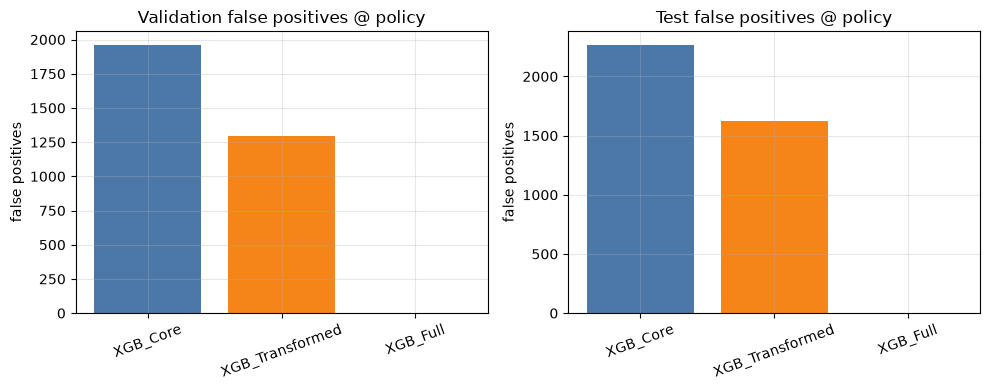

In [4]:
def delta_table(frame: pd.DataFrame) -> pd.DataFrame:
    indexed = frame.set_index("model")
    rows = []
    for start, end in (("XGB_Core", "XGB_Transformed"), ("XGB_Transformed", "XGB_Full"), ("XGB_Core", "XGB_Full")):
        a = indexed.loc[start]
        b = indexed.loc[end]
        rows.append({
            "transition": f"{start} → {end}",
            "Δ PR-AUC": b["PR-AUC"] - a["PR-AUC"],
            "Δ ROC-AUC": b["ROC-AUC"] - a["ROC-AUC"],
            "Δ Precision": b["Precision"] - a["Precision"],
            "Δ Recall": b["Recall"] - a["Recall"],
            "Δ False Positives": int(b["False Positives"] - a["False Positives"]),
            "Δ Alert Rate": b["Alert Rate"] - a["Alert Rate"],
        })
    return pd.DataFrame(rows)

print("Validation deltas:")
display(delta_table(val_ablation))
print("Test deltas:")
display(delta_table(test_ablation))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, frame, title in (
    (axes[0], val_ablation, "Validation"),
    (axes[1], test_ablation, "Test"),
):
    ax.bar(frame["model"], frame["False Positives"], color=["#4C78A8", "#F58518", "#54A24B"])
    ax.set_title(f"{title} false positives @ policy")
    ax.set_ylabel("false positives")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 4. Optional Logistic Regression diagnostic

Repeat engineered LogReg **without** `amount_to_balance_ratio` and `amount_exceeds_balance`, versus the unchanged Task 3 Model B (full engineered set).

In [5]:
logreg_configs = {
    "LogReg_Transformed": LOGREG_TRANSFORMED_FEATURES,
    "LogReg_Full_ModelB": ENGINEERED_MODEL_FEATURES,
}

def logreg_builder(feature_names):
    if tuple(feature_names) == tuple(ENGINEERED_MODEL_FEATURES):
        return build_logistic_engineered_pipeline()
    return build_logistic_feature_pipeline(feature_names)

logreg_results = []
for name, feats in logreg_configs.items():
    logreg_results.append(evaluate_config(name, feats, logreg_builder))

val_logreg = metrics_table(logreg_results, "val")
test_logreg = metrics_table(logreg_results, "test")
print("LogReg validation:")
display(val_logreg)
print("LogReg test:")
display(test_logreg)

LogReg_Transformed: threshold=0.635000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).


LogReg_Full_ModelB: threshold=0.919000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).
LogReg validation:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,False Negatives,Alert Rate
0,LogReg_Transformed,0.175099,0.961691,0.635000,0.013241,0.800000,0.026050,33387,112,0.081407
1,LogReg_Full_ModelB,0.481893,0.998728,0.919000,0.315531,0.801786,0.452849,974,111,0.003424


LogReg test:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,False Negatives,Alert Rate
0,LogReg_Transformed,0.370835,0.958525,0.635000,0.077733,0.809701,0.141849,38619,765,0.100587
1,LogReg_Full_ModelB,0.898218,0.998781,0.919000,0.757377,0.804478,0.780217,1036,786,0.010257


## 5. Recommendation

Separate **best score on PaySim** from **best model for portfolio deployment**.

Deployment preference weighs operational FP reduction, simplicity, and robustness of the signal once explicit simulator-drain encodings are removed.

In [6]:
# Assemble a compact recommendation view from XGB ablation + LogReg transformed/full
rec_rows = []
for r in xgb_results + logreg_results:
    m = r["test"]
    rec_rows.append({
        "candidate": r["name"],
        "test_PR_AUC": m["average_precision"],
        "test_precision": m["precision"],
        "test_recall": m["recall"],
        "test_FP": m["false_positives"],
        "test_FN": m["false_negatives"],
        "n_features": len(r["features"]),
        "uses_explicit_drain_features": bool(set(r["features"]) & set(BALANCE_DRAIN_FEATURE_NAMES)),
    })
rec = pd.DataFrame(rec_rows).sort_values(["uses_explicit_drain_features", "test_FP", "n_features"])
display(rec)

# Deterministic recommendation logic for the notebook narrative:
# Prefer models without explicit drain features when they retain ~80% recall with
# material FP reduction vs Core; otherwise acknowledge Full as PaySim-best only.
core_fp = int(rec.loc[rec["candidate"] == "XGB_Core", "test_FP"].iloc[0])
trans = rec.loc[rec["candidate"] == "XGB_Transformed"].iloc[0]
full = rec.loc[rec["candidate"] == "XGB_Full"].iloc[0]
log_t = rec.loc[rec["candidate"] == "LogReg_Transformed"].iloc[0]
log_f = rec.loc[rec["candidate"] == "LogReg_Full_ModelB"].iloc[0]

paysim_best = full["candidate"]  # by construction the strongest on this simulator

# Deployment pick: among candidates without explicit drain features that keep recall>=75%
# (soft; threshold was validation-only), choose lowest FP then fewest features.
robust = rec.loc[
    (~rec["uses_explicit_drain_features"]) & (rec["test_recall"] >= DEFAULT_RECALL_FLOOR - 0.05)
]
if robust.empty:
    deployment = "XGB_Transformed"
    deploy_reason = (
        "No non-drain model met the soft recall band; default to XGB_Transformed as the "
        "least simulator-specific boosted configuration short of Full."
    )
else:
    robust = robust.sort_values(["test_FP", "n_features", "candidate"])
    deployment = robust.iloc[0]["candidate"]
    deploy_reason = (
        f"Among models without explicit drain encodings, {deployment} has the best "
        f"false-positive profile near the ~80% recall policy, with fewer PaySim-specific shortcuts."
    )

print("=" * 72)
print("PaySim-best score:", paysim_best)
print("Recommended for portfolio deployment:", deployment)
print(deploy_reason)
print()
print(
    "Interpretation: large Core→Full gains concentrated in Transformed→Full "
    "(adding amount_to_balance_ratio / amount_exceeds_balance) indicate simulator artifact "
    "risk rather than temporal leakage."
)
print(
    f"Reference — XGB_Core FP={core_fp:,}; XGB_Transformed FP={int(trans['test_FP']):,}; "
    f"XGB_Full FP={int(full['test_FP']):,}; LogReg_Transformed FP={int(log_t['test_FP']):,}; "
    f"LogReg_Full FP={int(log_f['test_FP']):,}."
)

,candidate,test_PR_AUC,test_precision,test_recall,test_FP,test_FN,n_features,uses_explicit_drain_features
1,XGB_Transformed,0.861360,0.670128,0.818657,1620,729,6,False
0,XGB_Core,0.830741,0.590392,0.813184,2268,751,3,False
3,LogReg_Transformed,0.370835,0.077733,0.809701,38619,765,6,False
2,XGB_Full,0.999775,1.0000,0.996517,0,14,8,True
4,LogReg_Full_ModelB,0.898218,0.757377,0.804478,1036,786,8,True


PaySim-best score: XGB_Full
Recommended for portfolio deployment: XGB_Transformed
Among models without explicit drain encodings, XGB_Transformed has the best false-positive profile near the ~80% recall policy, with fewer PaySim-specific shortcuts.

Interpretation: large Core→Full gains concentrated in Transformed→Full (adding amount_to_balance_ratio / amount_exceeds_balance) indicate simulator artifact risk rather than temporal leakage.
Reference — XGB_Core FP=2,268; XGB_Transformed FP=1,620; XGB_Full FP=0; LogReg_Transformed FP=38,619; LogReg_Full FP=1,036.


## 6. Conclusions

1. **Not temporal leakage** — audited features use only pre-authorization fields.
2. **Simulator artifact** — if fraud rows disproportionately show `amount ≈ oldbalanceOrg` / amount exceeding balance, explicit drain features can act as a synthetic shortcut.
3. **Ablation** — comparing XGB Core → Transformed → Full isolates how much near-perfect performance depends on those encodings.
4. **Deployment** — prefer a model that remains useful after removing explicit drain features; treat XGB Full as PaySim-best, not automatically portfolio-best.

Task 3 results remain unchanged as a reference; this notebook is diagnostic only.